In [74]:
import pandas as pd
import polars as pl
import numpy as np

from scipy.stats import bootstrap

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import NullFormatter

In [88]:
scores_file = "../output/eval_latest/hub/rel_crps_cfa_models_by_t_loc.parquet"

cols = ["location", "forecast_date"]
data_col = "log_mean_scores_ratio"
stat = np.mean
rng = np.random.default_rng(seed=123)
pointcolor = "darkgreen"

In [89]:
df = (
    pl.read_parquet(scores_file)
    .filter(pl.col("model") == "cfa-wwrenewal(retro)")
    .with_columns(log_mean_scores_ratio=pl.col("mean_scores_ratio").log())
    .select("forecast_date", "location", data_col)
    .to_pandas()
)

In [90]:
df

,forecast_date,location,log_mean_scores_ratio
0,2023-10-16,AZ,0.160646
1,2023-10-16,CA,-0.044679
2,2023-10-16,CO,0.026887
3,2023-10-16,DE,-0.383433
4,2023-10-16,FL,0.033740
...,...,...,...
769,2024-03-25,VA,1.073320
770,2024-03-25,VT,0.001752
771,2024-03-25,WA,0.076529
772,2024-03-25,WI,0.396159


In [91]:
out = {}

for c in cols:
    out[c] = []
    for k, g in df.groupby(c):
        vals = g[data_col].to_numpy()
        res = bootstrap(
            (vals,), stat, confidence_level=0.95, method="percentile"
        )
        out[c].append(
            {
                c: k,
                "estimate": stat(vals),
                "ci_lo": res.confidence_interval.low,
                "ci_hi": res.confidence_interval.high,
                "n_vals": len(vals),
            }
        )

In [92]:
cols_log = ["estimate", "ci_lo", "ci_hi"]

df_loc = pd.DataFrame(out["location"])
df_loc[cols_log] = np.exp(df_loc[cols_log])

df_date = pd.DataFrame(out["forecast_date"])
df_date[cols_log] = np.exp(df_date[cols_log])
df_date["forecast_date"] = pd.to_datetime(df_date["forecast_date"])

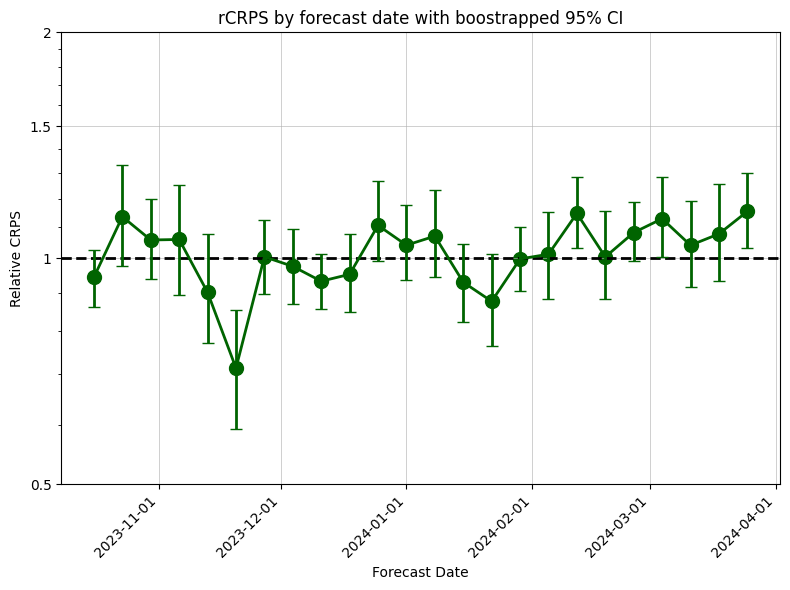

In [93]:
df_plot = df_date.sort_values("forecast_date").copy()

x = df_plot["forecast_date"]
y = df_plot["estimate"]
y_lo = df_plot["ci_lo"]
y_hi = df_plot["ci_hi"]

fig, ax = plt.subplots(figsize=(8, 6))

ax.axhline(y=1, ls="dashed", lw=2, color="k")
ax.plot(x, y, linewidth=2, color=pointcolor)
ax.scatter(x, y, s=100, color=pointcolor)  # size ~ 6**2

yerr = np.vstack([y - y_lo, y_hi - y])
ax.errorbar(
    x, y, yerr=yerr, fmt="none", capsize=4, linewidth=2, color=pointcolor
)

ax.set_yscale("log")
ax.set_ylim(0.5, 2)

ticks = [0.5, 1, 1.5, 2]
ax.set_yticks(ticks)
ax.set_yticklabels([str(t) for t in ticks])

ax.yaxis.set_minor_formatter(NullFormatter())

ax.yaxis.set_minor_locator(
    ticker.LogLocator(base=10, subs=np.arange(0.5, 2, 0.1))
)

ax.set_title("rCRPS by forecast date with boostrapped 95% CI")
ax.set_xlabel("Forecast Date")
ax.set_ylabel("Relative CRPS")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")  # similar to 0.8 rad

ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.7)

plt.tight_layout()

plt.savefig("ratio_forecast_date.png")

plt.show()

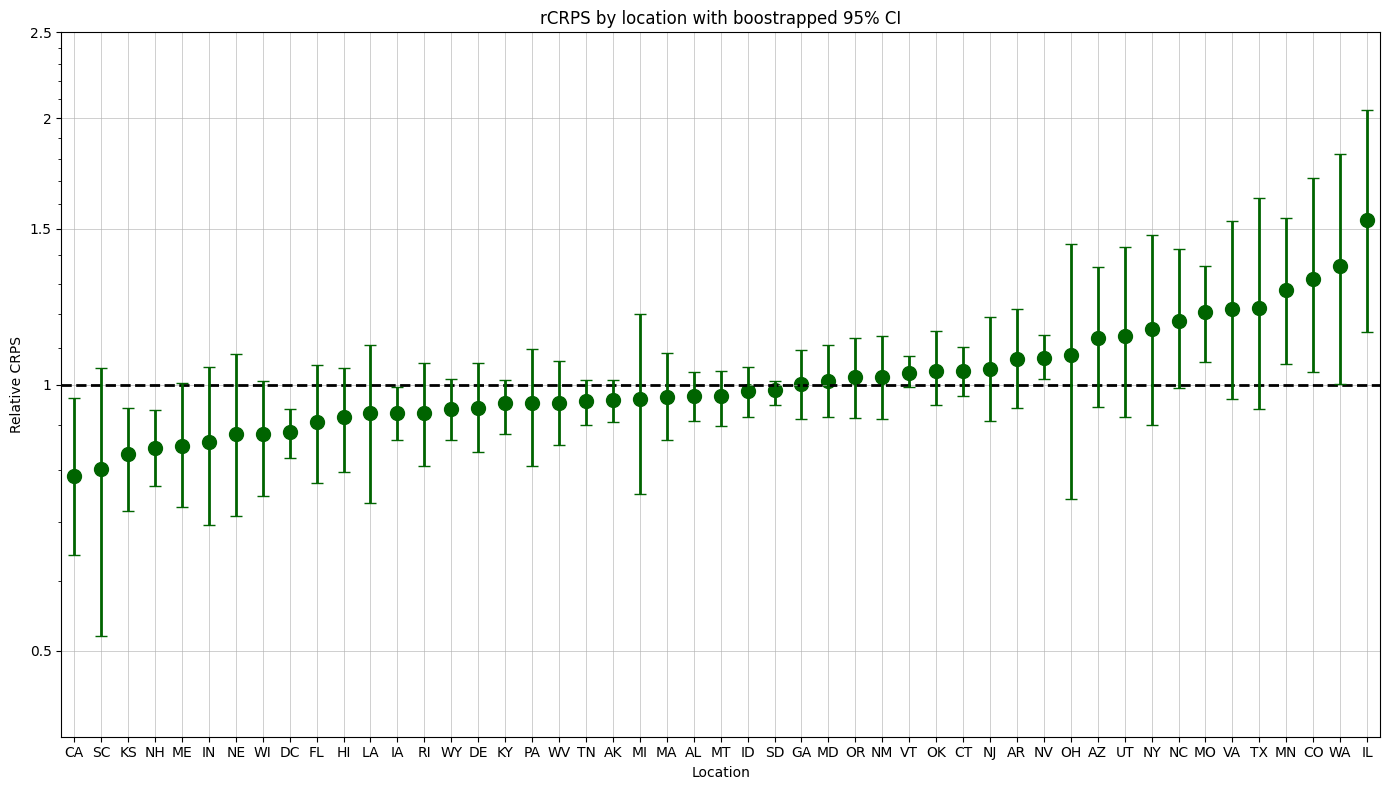

In [98]:
df_plot = df_loc.sort_values("estimate").copy()

x = df_plot["location"]
y = df_plot["estimate"]
y_lo = df_plot["ci_lo"]
y_hi = df_plot["ci_hi"]

fig, ax = plt.subplots(figsize=(14, 8))

ax.axhline(y=1, lw=2, ls="dashed", color="k")
ax.scatter(x, y, s=100, color=pointcolor)

yerr = np.vstack([y - y_lo, y_hi - y])
ax.errorbar(
    x, y, yerr=yerr, fmt="none", capsize=4, linewidth=2, color=pointcolor
)

ax.set_yscale("log")
ax.set_ylim(1 / 2.5, 2.5)

ticks = [0.5, 1, 1.5, 2, 2.5]
ax.set_yticks(ticks)
ax.set_yticklabels([str(t) for t in ticks])

ax.yaxis.set_minor_formatter(NullFormatter())

ax.yaxis.set_minor_locator(
    ticker.LogLocator(base=10, subs=np.arange(0.5, 2.5, 0.1))
)

ax.set_title("rCRPS by location with boostrapped 95% CI")
ax.set_xlabel("Location")
ax.set_ylabel("Relative CRPS")

ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.7)
ax.margins(x=0.01)

plt.tight_layout()

plt.savefig("ratio_location.png")

plt.show()

In [11]:
df_loc.estimate.mean()

np.float64(1.0371936037250493)

In [12]:
df_date.estimate.mean()

np.float64(1.0333592802253604)